# LangGraph Crash Course

This notebook builds four small LangGraph examples using Pydantic models to structure state.

In [9]:
from typing import Any, List
from IPython.display import Image, display
from langgraph.graph import StateGraph, END , START
from pydantic import BaseModel, Field

from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from typing_extensions import Annotated, List
from typing import Literal

import rich

import operator
import sys 

sys.path.insert(0,"../code")


In [10]:
from utils_import import *

In [8]:


# Initialize tracer (no-op if optional instrumentation is not installed)
tracer

## About LangGraph

LangGraph is an open-source framework for building, managing, and deploying complex, stateful AI agent workflows using a **graph** based architecture.

Graphs are composed of nodes, edges.


`Node`: python Functions.    

`Edges`: transition between nodes. Edges can be
- Serial
- Parallel
- Conditional

`State`: python object accessible during graph execution. Best to use an instance of TypedDict, dataclass, or pydantic class



## Graph 1: Simple Math example

Given two numbers, can you calulate the sum of them and the product of them.


here is a simple pydantic model that will be used as for the graph state.

`a` and `b` will be used as inputs.

`total_sum` and `total_multiply` and `total_final` will store outputs

In [20]:
class MathState(BaseModel):
    a: int
    b: int
    
    total_sum: int | None = None
    total_multiply: int | None = None
    total_final: int | None = None

edges of a graph.

they take a state object as input and return a dictionary of outputs to be merged into the state.

because edges can be updated in parallel, you should not mutate the input

In [22]:
def compute_sum(state: MathState) -> MathState:
    return {"total_sum": state.a + state.b}

def compute_product(state: MathState) -> MathState:
    return {"total_multiply": state.a * state.b}

def compute_final(state: MathState) -> MathState:
    return {"total_final": state.total_sum + state.total_multiply}

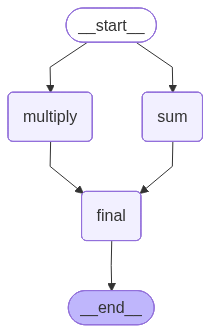

In [ ]:
workflow_math = StateGraph(MathState)

workflow_math.add_node("sum", compute_sum)
workflow_math.add_node("multiply", compute_product)
workflow_math.add_node("final", compute_final)
workflow_math.add_edge(START, "sum")
workflow_math.add_edge(START, "multiply")

workflow_math.add_edge("sum", "final")
workflow_math.add_edge("multiply", "final")
workflow_math.add_edge("final", END)

graph_math = workflow_math.compile()
display(Image(graph_math.get_graph().draw_mermaid_png()))




In [ ]:
with tracer.start_as_current_span("graph_math"):
    res = graph_math.invoke(MathState(a=2, b=5))

res

{'a': 2, 'b': 5, 'total_sum': 7, 'total_multiply': 10, 'total_final': 17}

## Graph 2: Graph with conditional edges

In [33]:
class ConditionalState(BaseModel):
    number: int
    final_message: str = None

In [34]:
def add_one_node(state:ConditionalState) -> ConditionalState:
    return {"number": state.number + 1}

def even_node(state:ConditionalState) -> ConditionalState:
    return {"final_message":"number is even"}

def odd_node(state:ConditionalState) -> ConditionalState:
    return {"final_message":"number is odd"}

def number_checker_condition(state:ConditionalState) ->Literal["even","odd"]:
    if state.number % 2 == 0:
        return "even"
    else:
        return "odd"

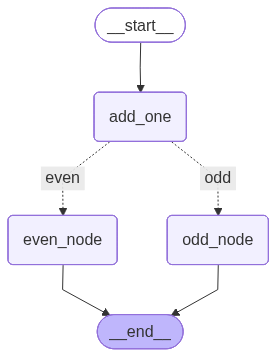

In [35]:
# Build the graph
workflow_conditional = StateGraph(ConditionalState)

# Add nodes
workflow_conditional.add_node("add_one", add_one_node)
workflow_conditional.add_node("even_node", even_node)
workflow_conditional.add_node("odd_node", odd_node)

workflow_conditional.add_edge(START, "add_one")
workflow_conditional.add_edge("odd_node",END)
workflow_conditional.add_edge("even_node",END)

# Add conditional edges depending on number
workflow_conditional.add_conditional_edges(
    "add_one",
    number_checker_condition,
    {"even": "even_node", "odd": "odd_node"}
)

# Compile the graph
graph_conditional = workflow_conditional.compile()
graph_conditional

In [36]:
with tracer.start_as_current_span("graph_conditional"):
    res = graph_conditional.invoke(ConditionalState(number=3))

res

{'number': 4, 'final_message': 'number is even'}

## Simple Research Flow
Takes an initial query, generates follow-up prompts, fabricates findings, then aggregates them.

In [ ]:
class ResearchState(BaseModel):
    query: str
    sub_queries: List[str] = Field(default_factory=list)
    raw_notes: Annotated[list[str], operator.add] = []
    final_report: str = None

def expand_queries(state: ResearchState) -> dict[str, Any]:
    suggestions = [
        f"{state.query} overview",
        f"{state.query} challenges",
        f"{state.query} opportunities",
    ]
    return {"sub_queries": suggestions}

def gather_research(state: ResearchState) -> dict[str, Any]:
    raw_notes = [f"Research for '{item}': placeholder insight." for item in state.sub_queries]
    return {"raw_notes": raw_notes}

def summarize_research(state: ResearchState) -> dict[str, Any]:
    
    research_report = f"""
    # Introduction

    user queried about : {state.query}

    # Findings
    {state.raw_notes}

    # Conclusion
    {state.final_report}


    """
    
    return {"final_report": research_report}



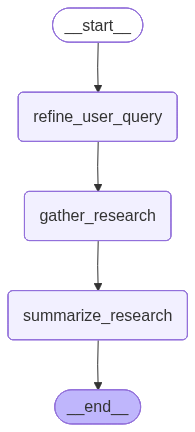

In [ ]:
workflow_research = StateGraph(ResearchState)
workflow_research.add_node("refine_user_query", expand_queries)
workflow_research.add_node("gather_research", gather_research)
workflow_research.add_node("summarize_research", summarize_research)
workflow_research.set_entry_point("refine_user_query")
workflow_research.add_edge("refine_user_query", "gather_research")
workflow_research.add_edge("gather_research", "summarize_research")
workflow_research.add_edge("summarize_research", END)

graph_research = workflow_research.compile()
display(Image(graph_research.get_graph().draw_mermaid_png()))



In [ ]:
graph_research.invoke(ResearchState(query="AI Agents"))



{'query': 'AI Agents',
 'sub_queries': ['AI Agents overview',
  'AI Agents challenges',
  'AI Agents opportunities'],
 'raw_notes': ["Research for 'AI Agents overview': placeholder insight.",
  "Research for 'AI Agents challenges': placeholder insight.",
  "Research for 'AI Agents opportunities': placeholder insight."],
 'final_report': '\n    # Introdfuction\n\n    user queried about : AI Agents\n\n    # Findings\n    ["Research for \'AI Agents overview\': placeholder insight.", "Research for \'AI Agents challenges\': placeholder insight.", "Research for \'AI Agents opportunities\': placeholder insight."]\n\n    # Conclusion\n    None\n\n\n    '}

## Tool Calling

In [ ]:
Large Language Models generate text. 
As we saw in the weather example, they dont have access to outside information .

In order to bypass this limitation, we can provide function definitions 

In [37]:
model = ChatOpenAI(
    model="gpt-4o-mini",
    base_url=OPENAI_BASE_URL,
    #temperature=0.2,
    #max_tokens=512,
)

In [38]:
@tool
def animal_joke(animal: str) -> str:
    """Return a short, clean joke for turtle/cat/dog (falls back to dog)."""

    JOKES = {
    "turtle": "Why don’t turtles use public Wi-Fi? Too many shell networks.",
    "cat":    "Why did the cat sit on the computer? To keep an eye on the mouse.",
    "dog":    "What do you call a dog that does magic? A labracadabrador.",
    }
    return JOKES.get((animal or "").lower().strip(), JOKES["dog"])

tool_model = model.bind_tools([animal_joke])  # for tool calling


# ---- Build messages explicitly (System + Human) ----
animal = "turtle"
messages = [
    SystemMessage(content="You are a concise jokester."),
    HumanMessage(content=f"Tell me a short, clean joke about {animal}."),
]




In [29]:
with tracer.start_as_current_span("tool_calling_example"):
    
    ai_msg = tool_model.invoke(
        messages
    )
    
    print(f"Message generated from our llm call")
    rich.print(ai_msg)


    # get tool call and arguments
    tc = ai_msg.tool_calls[0]         
    
    # invoke tool call
    tool_result = animal_joke.invoke(tc["args"] )

    # tool output result
    print(f"tool output result")
    rich.print(tool_result)

Message generated from our llm call


AIMessage(
    content='',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 17,
            'prompt_tokens': 73,
            'total_tokens': 90,
            'completion_tokens_details': {
                'accepted_prediction_tokens': 0,
                'audio_tokens': 0,
                'reasoning_tokens': 0,
                'rejected_prediction_tokens': 0
            },
            'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}
        },
        'model_provider': 'openai',
        'model_name': 'gpt-4o-mini-2024-07-18',
        'system_fingerprint': 'fp_560af6e559',
        'id': 'chatcmpl-CT1i4R9tmhflwnKEG1JIP2KlENmRa',
        'service_tier': 'default',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--dd6c2471-6bda-40e9-8450-d4c4d1647cba-0',
    tool_calls=[
        {
            'name': 'animal_joke',
            'args': {'animal': 'turtle'},
            'id': 'call_Flg0BzoFbM8JkEDRfcR4icaz',
            'type': 'tool_call'
        }
    ],
    usage_metadata={
        'input_tokens': 73,
        'output_tokens': 17,
        'total_tokens': 90,
        'input_token_details': {'audio': 0, 'cache_read': 0},
        'output_token_details': {'audio': 0, 'reasoning': 0}
    }
)

tool output result


Why don’t turtles use public Wi-Fi? Too many shell networks.

AIMessage(
    content='',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 17,
            'prompt_tokens': 73,
            'total_tokens': 90,
            'completion_tokens_details': {
                'accepted_prediction_tokens': 0,
                'audio_tokens': 0,
                'reasoning_tokens': 0,
                'rejected_prediction_tokens': 0
            },
            'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}
        },
        'model_provider': 'openai',
        'model_name': 'gpt-4o-mini-2024-07-18',
        'system_fingerprint': 'fp_560af6e559',
        'id': 'chatcmpl-CT1i4R9tmhflwnKEG1JIP2KlENmRa',
        'service_tier': 'default',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--9d7f4cad-a391-45dd-b4e6-4850365d8950-0',
    tool_calls=[
        {
            'name': 'animal_joke',
            'args': {'animal': 'turtle'},
            'id': 'call_Flg0BzoFbM8JkEDRfcR4icaz',
            'type': 'tool_call'
        }
    ],
    usage_metadata={
        'input_tokens': 73,
        'output_tokens': 17,
        'total_tokens': 90,
        'input_token_details': {'audio': 0, 'cache_read': 0},
        'output_token_details': {'audio': 0, 'reasoning': 0}
    }
)

Why don’t turtles use public Wi-Fi? Too many shell networks.

## Structured Outputs

In [41]:
class AnimalInfo(BaseModel):
    name:str
    first_discovered:str
    latin_name: str
    num_species:str

In [47]:
res = model.invoke("Tell me some facts about elephants.")
rich.print(res)

AIMessage(
    content="Sure! Here are some interesting facts about elephants:\n\n1. **Species**: There are three main species
of elephants—African bush elephants, African forest elephants, and Asian elephants. The African bush elephant is 
the largest of the three.\n\n2. **Size**: Adult elephants can weigh between 5,000 to 14,000 pounds (2,268 to 6,350 
kg) and can stand up to 13 feet (4 meters) tall at the trunk.\n\n3. **Trunks**: An elephant's trunk is a highly 
versatile tool used for various purposes, including feeding, drinking, and social interaction. It contains around 
40,000 muscles and serves as both an arm and a nose.\n\n4. **Communication**: Elephants are highly social animals 
and communicate using a variety of vocalizations, body language, and even infrasound (low-frequency sounds) that 
can travel long distances.\n\n5. **Intelligence**: Elephants are known for their high intelligence, exhibiting 
behaviors like problem-solving, tool use, and showing empathy. They have remarkable memories and can recognize 
individuals and places long after being separated.\n\n6. **Social Structure**: Elephants live in complex social 
groups. Female elephants (herds) usually consist of related females and their young, while adult males often leave 
their natal herds to live solitary lives or form small groups.\n\n7. **Lifespan**: Elephants can live long lives, 
often reaching into their 60s or even 70s in the wild. In captivity, they can live even longer with proper 
care.\n\n8. **Diet**: Elephants are herbivores and consume a wide variety of vegetation, including grasses, leaves,
fruits, and bark. An adult elephant can eat between 200 to 300 pounds (90 to 136 kg) of food per day.\n\n9. 
**Conservation Status**: Many elephant populations are threatened due to habitat loss, poaching for ivory, and 
human-elephant conflict. Conservation efforts are ongoing to protect these magnificent creatures and their 
habitats.\n\n10. **Cultural Significance**: Elephants hold significant cultural and spiritual value in many 
cultures around the world, often symbolizing wisdom, loyalty, and strength.\n\nThese gentle giants play a crucial 
role in their ecosystems, and their conservation is vital for maintaining biodiversity.",
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 469,
            'prompt_tokens': 14,
            'total_tokens': 483,
            'completion_tokens_details': {
                'accepted_prediction_tokens': 0,
                'audio_tokens': 0,
                'reasoning_tokens': 0,
                'rejected_prediction_tokens': 0
            },
            'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}
        },
        'model_provider': 'openai',
        'model_name': 'gpt-4o-mini-2024-07-18',
        'system_fingerprint': 'fp_560af6e559',
        'id': 'chatcmpl-CZKp8ejse4PDTLvzGorssxPKgLMMS',
        'service_tier': 'default',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--6c1a03d3-5396-400a-9cb0-fef0259c803a-0',
    usage_metadata={
        'input_tokens': 14,
        'output_tokens': 469,
        'total_tokens': 483,
        'input_token_details': {'audio': 0, 'cache_read': 0},
        'output_token_details': {'audio': 0, 'reasoning': 0}
    }
)

In [42]:
model_with_structured_output = model.with_structured_output(AnimalInfo)


In [45]:
res = model_with_structured_output.invoke("Tell me some facts about elephants.")
rich.print(res)

AnimalInfo(
    name='Elephants',
    first_discovered='Paleolithic period',
    latin_name='Loxodonta (African elephants) & Elephas (Asian elephants)',
    num_species='Three species: African savanna, African forest, and Asian elephant.'
)